In [60]:
import torch
from matplotlib import pyplot as plt
import numpy as np

from models.vqvae import VQVAE
from models.vqvae_2 import VQVAE2
from models.vqvae_finetune import VQVAE2FineTune
from dataset.vae_dataset import VAEDataset

# model = VQVAE.load_from_checkpoint(
#     "weights/vqvae.ckpt",
#     in_channels=5,
# )

# model = VQVAE.load_from_checkpoint(
#     "logs/vqvae_5channel_full_ds_32_64_128_128/c_256/checkpoints/epoch=29-step=68559.ckpt",
#     in_channels=5,
# )

model = VQVAE2.load_from_checkpoint("logs/vqvae_dim4_c8192/version_0/checkpoints/epoch=11-step=27612.ckpt")

# model = VQVAE2FineTune.load_from_checkpoint("logs/vqvae_new_finetune/version_5/checkpoints/epoch=4-step=23010.ckpt", lr=1e-3, vqvae=VQVAE2(5, 1e-3))

model = model.cpu()

ds = VAEDataset(path="train.memmap", channels=5, img_res=(128, 64))

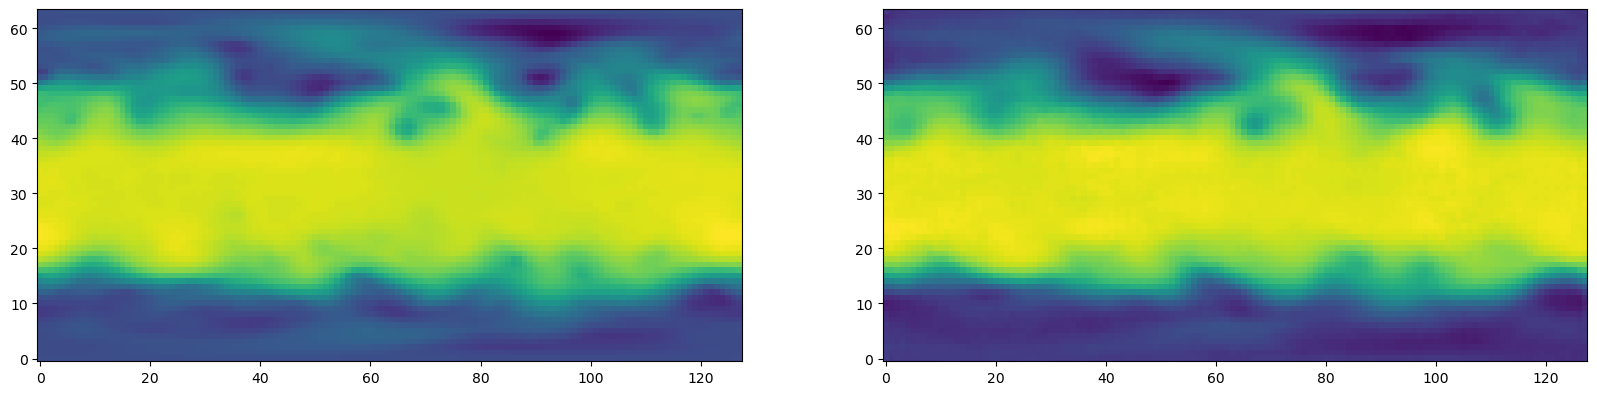

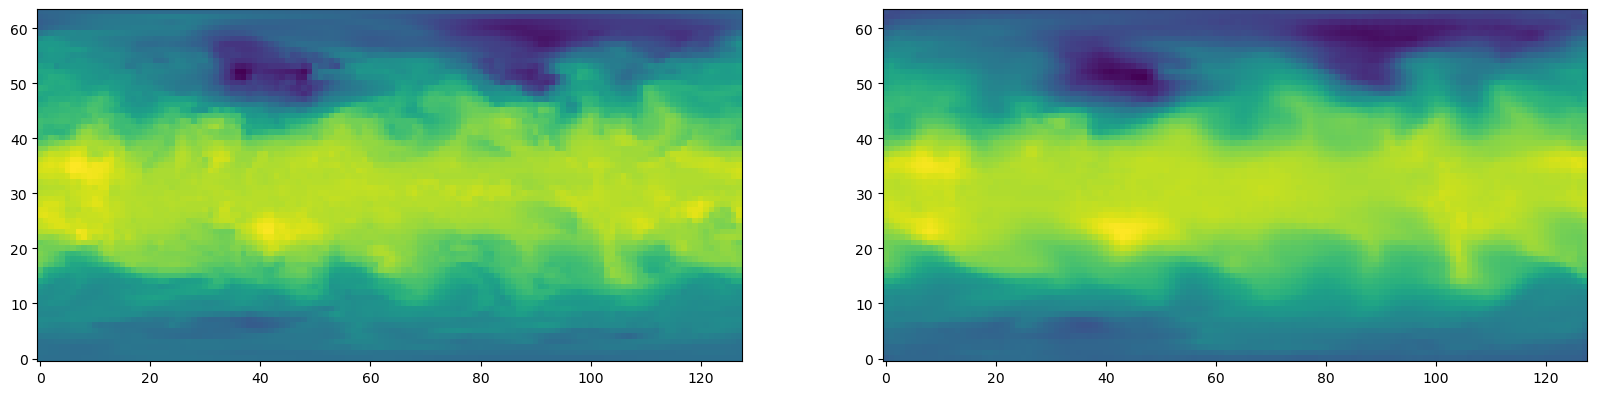

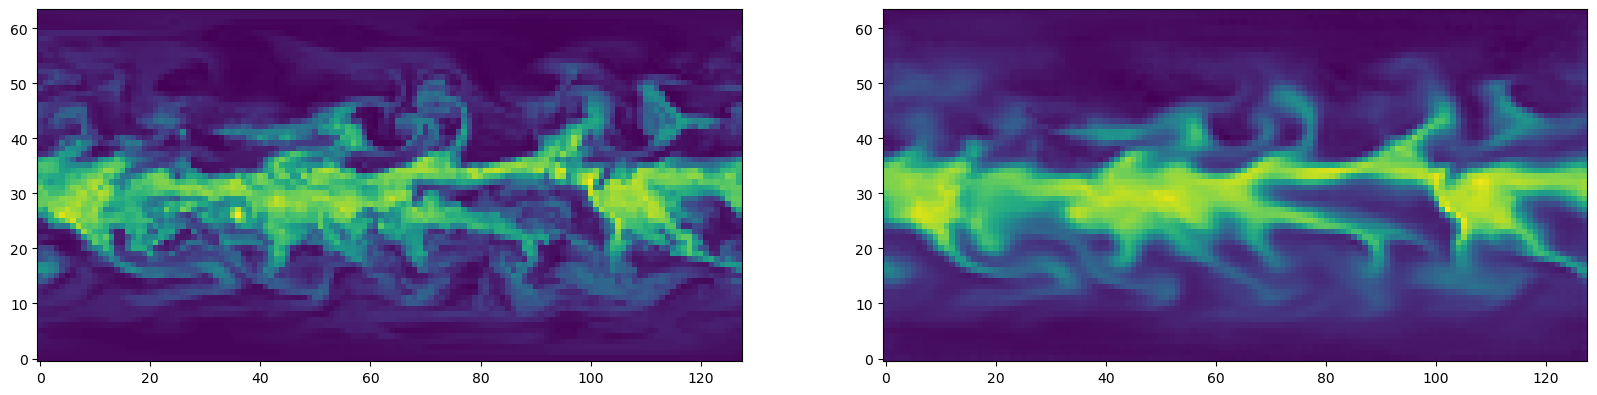

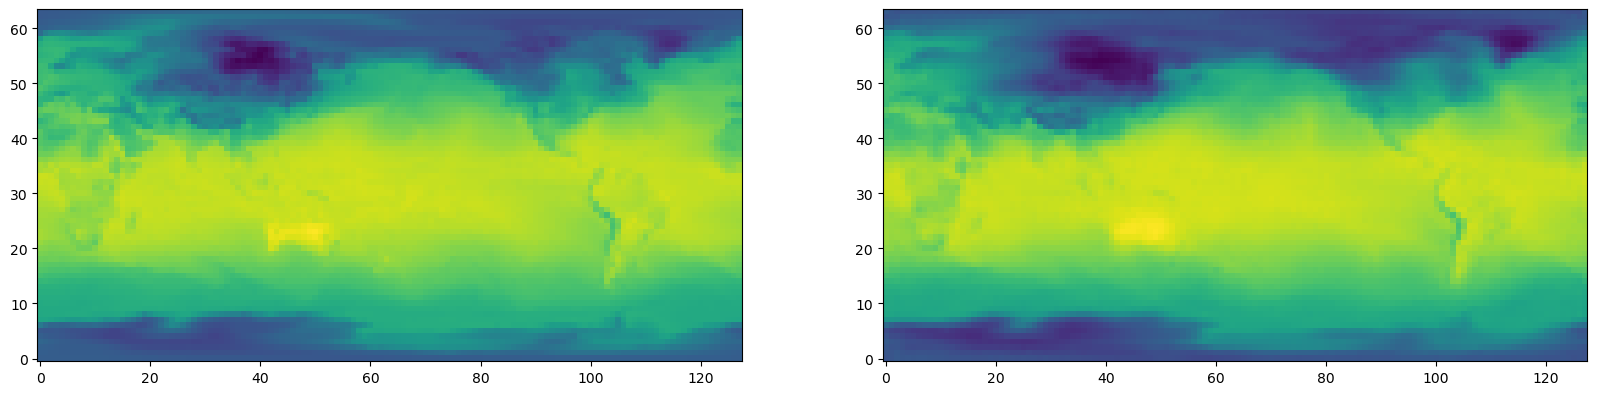

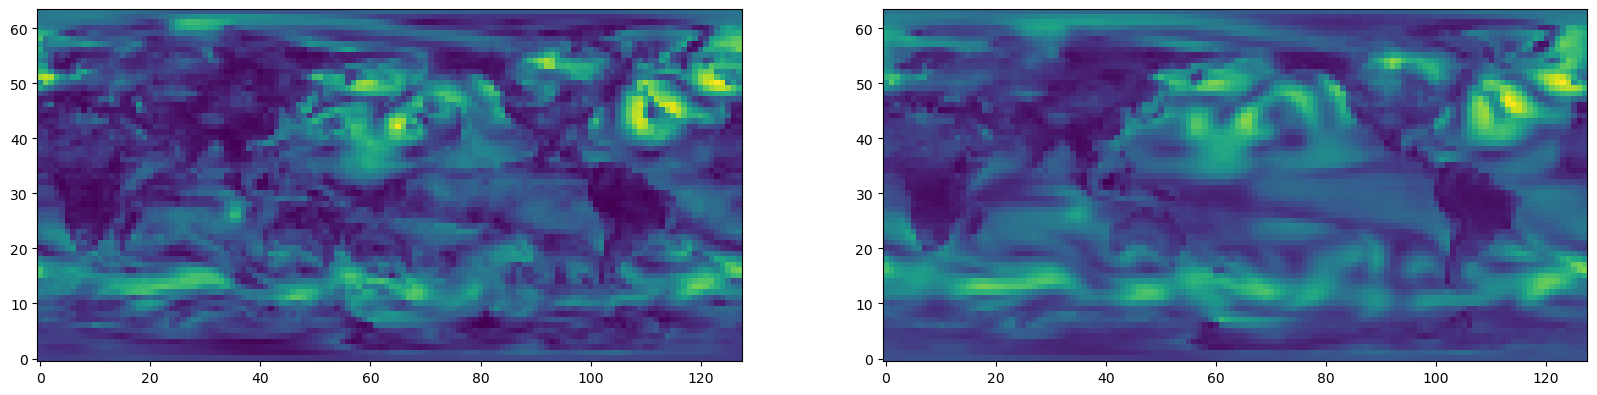

In [61]:
sample = torch.Tensor(ds[0])

prediction = model(sample.unsqueeze(0))

for i in range(5):
    fig, axs = plt.subplots(1, 2, figsize=(20, 10))
    axs[0].imshow(sample[i].numpy().T, origin="lower")
    axs[1].imshow(prediction[0][0][i].detach().numpy().T, origin="lower")
    plt.show()

torch.Size([1, 5, 128, 64]) torch.Size([1, 5, 128, 64])


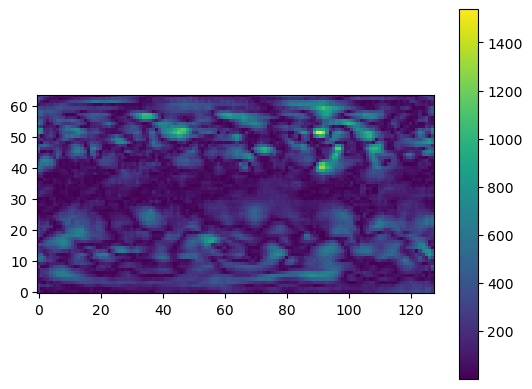

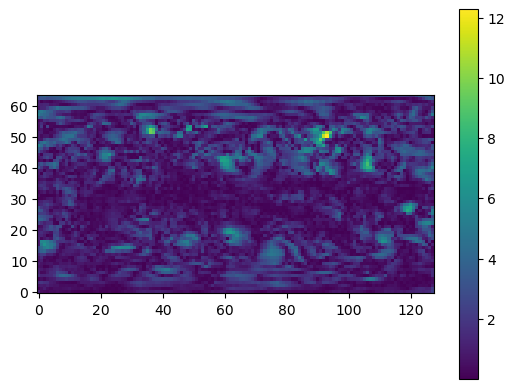

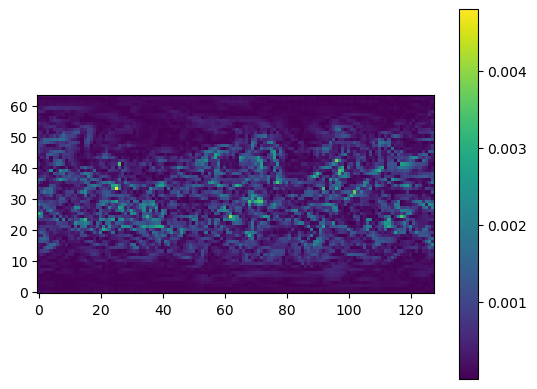

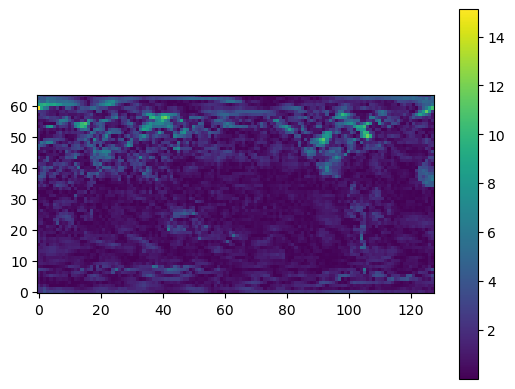

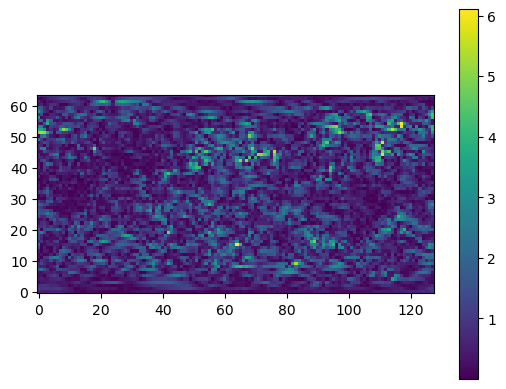

RMSE: 276.7516784667969


In [62]:
sample = torch.Tensor(ds[0]).unsqueeze(0)

prediction, latent, _ = model(sample)

print(sample.shape, prediction.shape)

sample = ds.denormalize_sample(sample.detach().numpy())
prediction = ds.denormalize_sample(prediction.detach().numpy())

for i in range(5):
    img = np.sqrt((sample[0][i].T - prediction[0][i].T)**2)
    # range between 0 and 1
    plt.imshow(img, origin="lower")
    plt.colorbar()
    plt.show()

t2m_rmse = np.sqrt(np.mean((sample[0][0].T - prediction[0][0].T)**2))
print(f"RMSE: {t2m_rmse}")

tensor(7.2736, grad_fn=<LinalgVectorNormBackward0>)


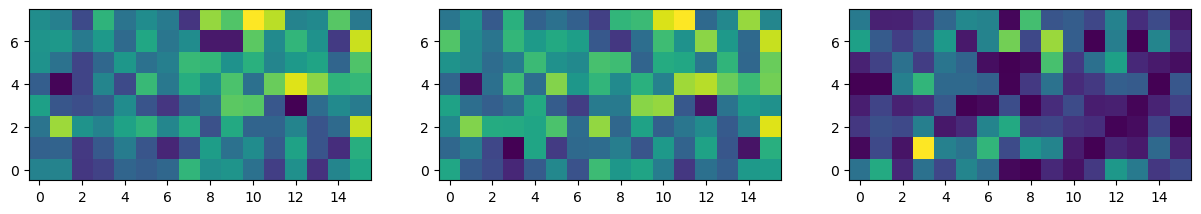

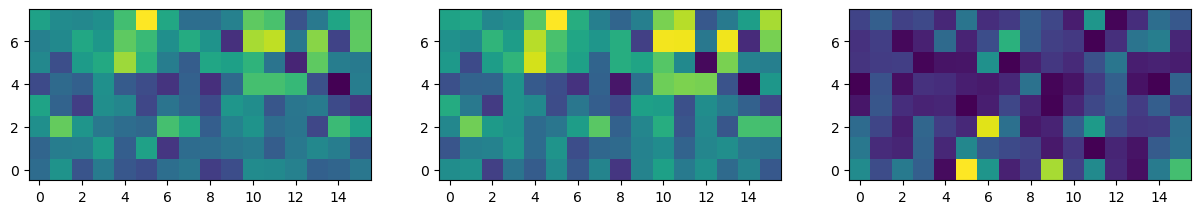

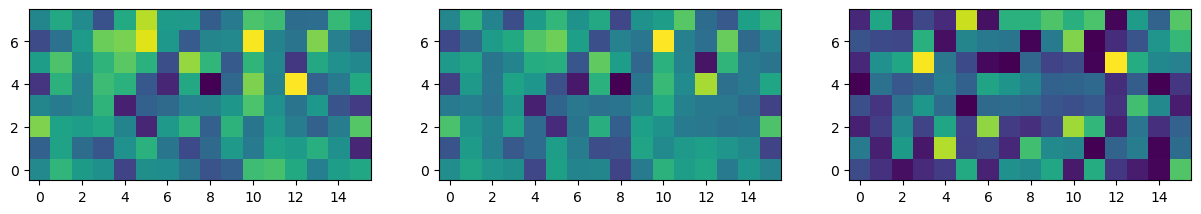

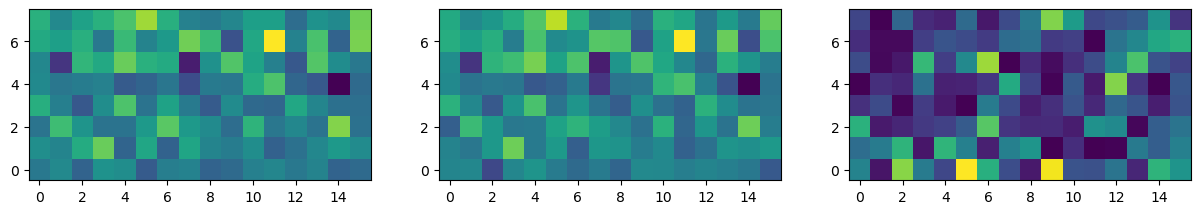

In [63]:
sample_1 = torch.Tensor(ds[0]).unsqueeze(0)
sample_2 = torch.Tensor(ds[1]).unsqueeze(0)

_, latent_1, _ = model(sample_1)
_, latent_2, _ = model(sample_2)

diff = latent_1 - latent_2

dist = torch.norm(diff, p=2)

diff = diff.detach().numpy()

diff = np.sqrt(diff **2)

print(dist)


for i in range(4):
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(latent_1[0][i].detach().numpy().T, origin="lower")
    axs[1].imshow(latent_2[0][i].detach().numpy().T, origin="lower")
    axs[2].imshow(diff[0, i].T, origin="lower")
    plt.show()

In [14]:
index_list = []

for _ in range(200):

    i = np.random.randint(0, len(ds))

    sample = torch.Tensor(ds[i]).unsqueeze(0)
    _, latent, _ = model(sample)
    _, _, index = model.quantize(latent)
    index_list.append(index)

indecies = torch.cat(index_list, dim=0)

# count all unique values
unique, counts = torch.unique(indecies, return_counts=True)
print(len(unique))

2458


In [7]:
# print model layers for layers the name includes "decoder"
for name, param in model.named_parameters():
    if "decoder" in name:
        print(name, param.shape)

decoder_conv_in.weight torch.Size([128, 8, 3, 3])
decoder_conv_in.bias torch.Size([128])
decoder_mid_blocks.0.resnet_blocks.0.0.weight torch.Size([128])
decoder_mid_blocks.0.resnet_blocks.0.0.bias torch.Size([128])
decoder_mid_blocks.0.resnet_blocks.0.2.weight torch.Size([128, 128, 3, 3])
decoder_mid_blocks.0.resnet_blocks.0.2.bias torch.Size([128])
decoder_mid_blocks.0.resnet_blocks.0.3.weight torch.Size([128])
decoder_mid_blocks.0.resnet_blocks.0.3.bias torch.Size([128])
decoder_mid_blocks.0.resnet_blocks.0.5.weight torch.Size([128, 128, 3, 3])
decoder_mid_blocks.0.resnet_blocks.0.5.bias torch.Size([128])
decoder_mid_blocks.0.resnet_blocks.1.0.weight torch.Size([128])
decoder_mid_blocks.0.resnet_blocks.1.0.bias torch.Size([128])
decoder_mid_blocks.0.resnet_blocks.1.2.weight torch.Size([128, 128, 3, 3])
decoder_mid_blocks.0.resnet_blocks.1.2.bias torch.Size([128])
decoder_mid_blocks.0.resnet_blocks.1.3.weight torch.Size([128])
decoder_mid_blocks.0.resnet_blocks.1.3.bias torch.Size([12